In [1]:
from roundel_clinical_utils import *

data_path = '/workspaces/Roundel-Clinical/roundel/data'
os.environ["CUDA_VISIBLE_DEVICES"]="0"

2026-03-12 16:26:06.551 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-12 16:26:06.950170: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-12 16:26:07.041342: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.8/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in Ma

In [2]:
patient = '1.3.6.1.4.1.53684.1.1.3.1671342546.2056.1623765873.123561'
image = load_nii(f'{data_path}/image___{patient}.nii.gz')
mask = load_nii(f'{data_path}/masks___{patient}.nii.gz')

In [3]:
ps = 1.172
thickness = 8.0

In [4]:
image = zoom(image, (ps,ps,1,1), order = 1)

In [5]:
model = tf.keras.models.load_model('UNet3plus.h5', 
                                   compile = False,
                                   custom_objects={"InstanceNormalization":InstanceNormalization,
                                                   "ResizeAndConcatenate":ResizeAndConcatenate})

2026-03-12 16:26:11.171920: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-03-12 16:26:11.173572: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-03-12 16:26:11.173717: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-03-12 16:26:11.174167: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags

In [ ]:
def segment_image(image):
    # Crop and pad the image to correct shape
    target_shape = (256,256)
    mask = []
    for t in range(image.shape[-1]):  
        image_cropped, meta =  crop_pad_image_only(image[..., t], target_shape = target_shape)
        X = z_normalise_image(image_cropped)[np.newaxis,...,np.newaxis]

        pred_mask = sliding_window_inference_3d(
                        model,
                        X,                   # np.ndarray [batch_size,Y,X,Z,1] already preprocessed & normalised
                        patch_size=[256,256,10],
                        overlap=0.5,
                        apply_softmax=False,       # set False as the model already uses softmax activation
                        out_channels=5,    # if known, can be set to avoid dry run
                        tta=False,                 # Whether to use test-time augmentation (flips)
                        plot_tta=False,           # Whether to plot the prediction after each TTA variant (for debugging)
                        scan_id = None,           # used for naming the TTA variant plots
                        time_step_counter=0, # used for naming the TTA variant plots
                        gaussian_sigma_scale=1/8, # controls how peaked the Gaussian is
                        deep_supervision=True,
                        run = None               # neptune run instance for logging
                    )
        pred_mask_one_hot = reverse_crop_pad(pred_mask, meta)
        pred_mask_one_hot = get_one_hot(pred_mask_one_hot.astype(np.uint8), 5)  # [Y0,X0,Z0,C_out]

        mask.append(pred_mask_one_hot)
    mask = np.stack(mask, -2)
    return mask

In [9]:
target_shape = (256,256)
mask = []
t = 0
image_cropped, meta =  crop_pad_image_only(image[..., t], target_shape = target_shape)
X = z_normalise_image(image_cropped)[np.newaxis,..., :10,np.newaxis]
mask = model.predict(X)

1/1 [==============================] - 0s 127ms/step


In [25]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 1  0           []                               
                                0, 1)]                                                            
                                                                                                  
 Encoder1_Conv_1 (Conv3D)       (None, 256, 256, 10  448         ['input_1[0][0]']                
                                , 16)                                                             
                                                                                                  
 Encoder1_IN_1 (InstanceNormali  (None, 256, 256, 10  32         ['Encoder1_Conv_1[0][0]']        
 zation)                        , 16)                                                         

In [76]:
import tensorflow as tf

# collect encoder and decoder activation layers automatically
encoder_layers = []
decoder_layers = []
skip_layers = []

for layer in model.layers:
    name = layer.name
    if name.startswith("Encoder") and "Activation" in name:
        encoder_layers.append(name)
    if name.startswith("Decoder") and "Activation" in name:
        decoder_layers.append(name)
    if name.startswith("Skip") and "Activation" in name:
        skip_layers.append(name)

layer_names = encoder_layers + decoder_layers + skip_layers

# build feature extractor
feature_model = tf.keras.Model(
    inputs=model.input,
    outputs=[model.get_layer(n).output for n in layer_names]
)

feature_maps = feature_model.predict(X)

n = len(feature_maps)

grid_rows = 3
grid_cols = (n + grid_rows - 1) // grid_rows



1/1 [==============================] - 2s 2s/step


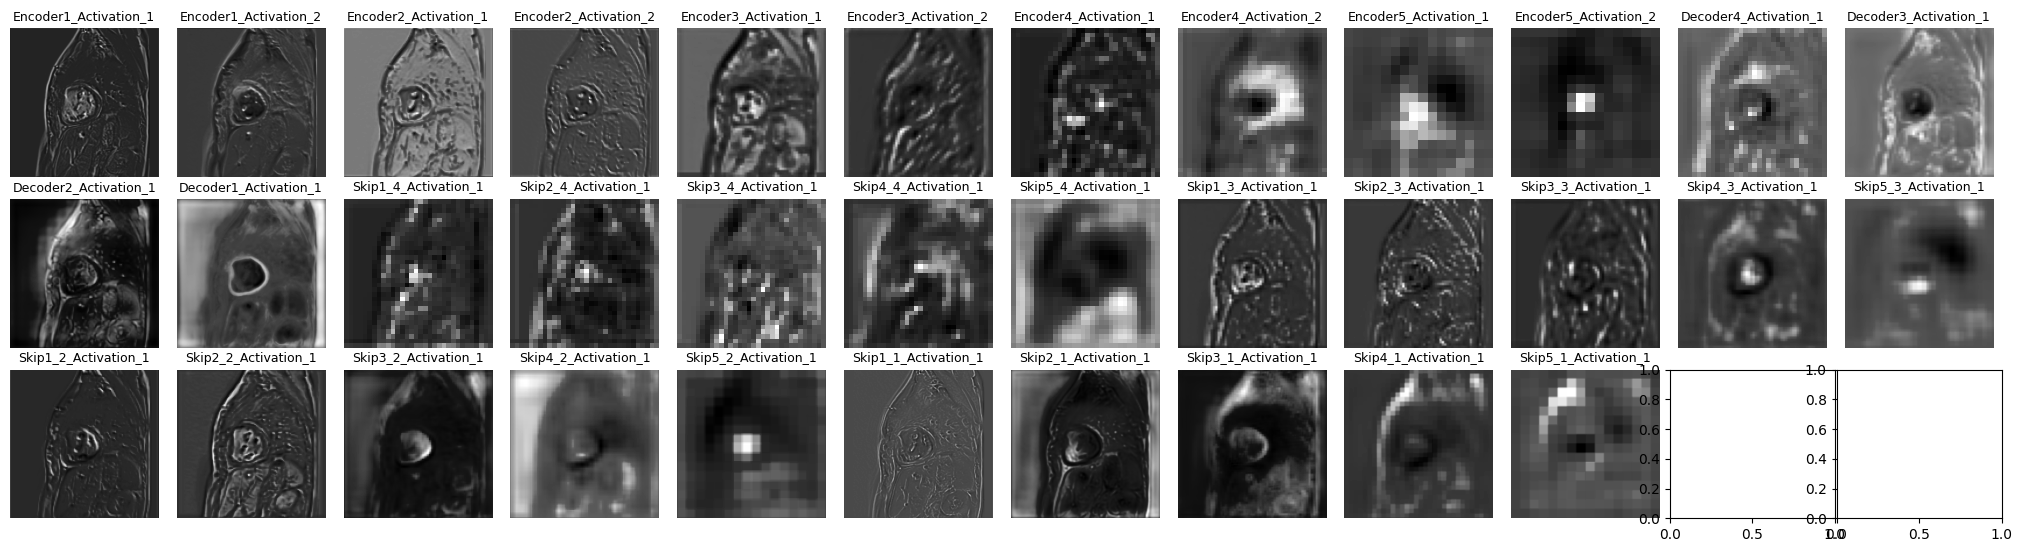

In [87]:

fig, axes = plt.subplots(grid_rows, grid_cols, figsize = (20,5))
axes = axes.ravel()

for i, fmap in enumerate(feature_maps):
    fmap = fmap[0]                           # remove batch
    fmap = fmap[:, :, fmap.shape[2]//2, 6]   # middle depth, first channel

    axes[i].imshow(fmap, 'gray')
    axes[i].set_title(layer_names[i], fontsize = 9)
    axes[i].axis("off")

plt.subplots_adjust(wspace = 0.01, left = 0, right = 1, bottom=0, top = 0.98, hspace=0.15)
plt.show()

In [ ]:
t = 5
s = 5
c = 1
plt.imshow(image[...,s,t], 'gray')
plt.imshow(mask[...,s, t, c], alpha = mask[...,s, t, c]/2)